In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados e engenharia de atributos inicial
df = pd.read_csv("/content/northstar_motor_telemetry.csv")
df['power_w'] = df['motor_voltage_v'] * df['motor_current_a']
df['temp_momentum'] = df['motor_temp_c'].diff(periods=5)
df['power_rolling_avg'] = df['power_w'].rolling(window=10).mean()

df['target_temp'] = df['motor_temp_c'].shift(-30)
df = df.dropna()

In [2]:
# Seleção de features e target brutos
features = ["motor_voltage_v", "motor_current_a", "power_w",
            "rpm", "ambient_temp_c", "motor_temp_c",
            "temp_momentum", "power_rolling_avg"]

x_raw = df[features].values
y_raw = df['target_temp'].values.reshape(-1, 1)

# Definindo o índice de divisão temporal (80% treino / 20% teste)
split_idx_raw = int(len(df) * 0.8)

x_train_raw, x_test_raw = x_raw[:split_idx_raw], x_raw[split_idx_raw:]
y_train_raw, y_test_raw = y_raw[:split_idx_raw], y_raw[split_idx_raw:]

# Ajustando os normalizadores APENAS nos dados de treino para evitar data leakage
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_raw)
x_test_scaled = scaler.transform(x_test_raw)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_raw).flatten()
y_test_scaled = target_scaler.transform(y_test_raw).flatten()

In [3]:
def criar_seq(dados_x, dados_y, tamanho_seq):
  xs, ys = [], []
  for i in range(len(dados_x) - tamanho_seq):
    xs.append(dados_x[i:(i + tamanho_seq)])
    ys.append(dados_y[i + tamanho_seq])
  return np.array(xs), np.array(ys)

# Criando sequências separadas para treino e teste para garantir o isolamento total
X_train, y_train_scaled = criar_seq(x_train_scaled, y_train_scaled, 30)
X_test, y_test_scaled = criar_seq(x_test_scaled, y_test_scaled, 30)

In [4]:
import torch

# Conversão direta para tensores PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

In [5]:
class MotorLSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers=1):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.linear = nn.Linear(hidden_size, 1)

  def forward(self, x):
    lstm_out, _ = self.lstm(x)
    last_time = lstm_out[:, -1, :]
    return self.linear(last_time)

In [6]:
# Inicialização do modelo e treinamento
model = MotorLSTM(input_size=8, hidden_size=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
loss_fn = nn.MSELoss()

epochs = 100
for epoch in range(epochs):
  model.train()
  prediction = model(X_train_t)
  loss = loss_fn(prediction, y_train_t)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch {epoch} | Loss (Normalizado): {loss.item():.4f}")

Epoch 0 | Loss (Normalizado): 1.0067
Epoch 10 | Loss (Normalizado): 0.2436
Epoch 20 | Loss (Normalizado): 0.0855
Epoch 30 | Loss (Normalizado): 0.0312
Epoch 40 | Loss (Normalizado): 0.0135
Epoch 50 | Loss (Normalizado): 0.0059
Epoch 60 | Loss (Normalizado): 0.0033
Epoch 70 | Loss (Normalizado): 0.0023
Epoch 80 | Loss (Normalizado): 0.0015
Epoch 90 | Loss (Normalizado): 0.0012


In [7]:
# Avaliação e desnormalização para graus Celsius
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

# Revertendo a normalização
y_pred_celsius = target_scaler.inverse_transform(y_pred_scaled)
y_true_celsius = target_scaler.inverse_transform(y_test_t.numpy())

mae_celsius = mean_absolute_error(y_true_celsius, y_pred_celsius)
rmse_celsius = np.sqrt(mean_squared_error(y_true_celsius, y_pred_celsius))
erro_max_celsius = max_error(y_true_celsius, y_pred_celsius)

print(f"Métricas de Validação (em °C):")
print(f"MAE: {mae_celsius:.4f} °C")
print(f"RMSE: {rmse_celsius:.4f} °C")
print(f"Erro Máximo: {erro_max_celsius:.4f} °C")

Métricas de Validação (em °C):
MAE: 0.3943 °C
RMSE: 0.5295 °C
Erro Máximo: 3.2932 °C


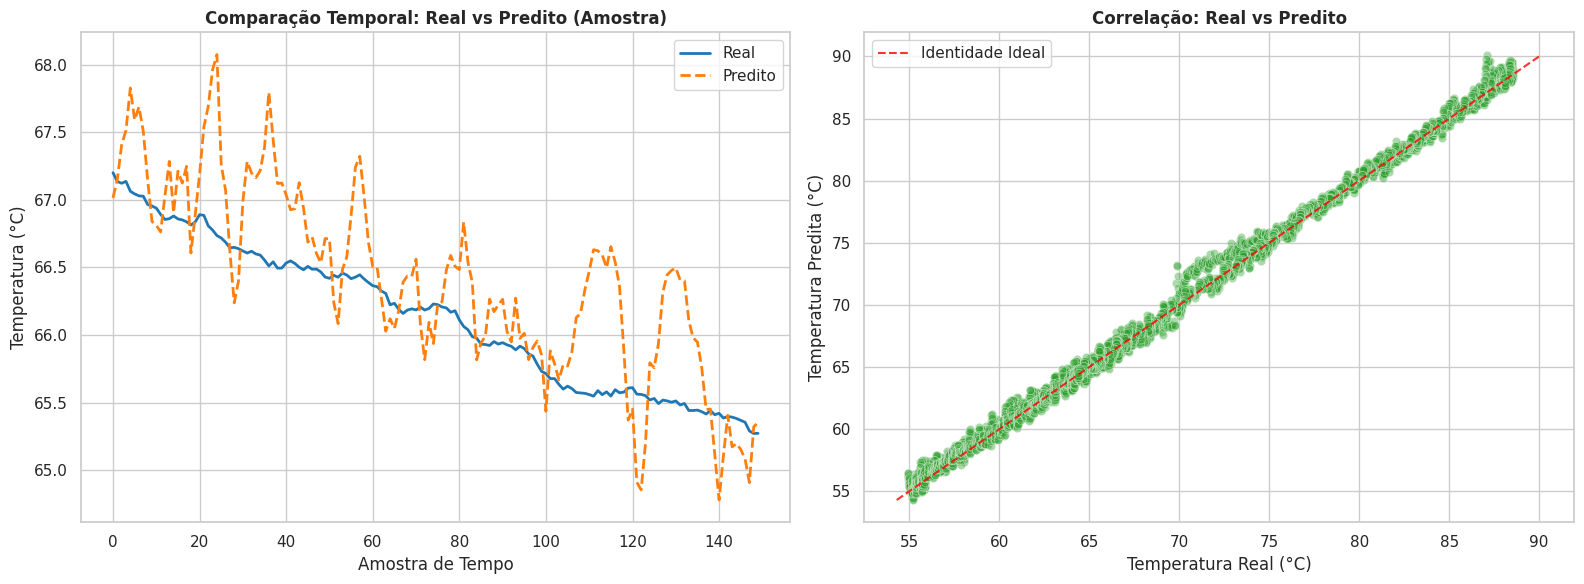

In [8]:
# Visualização dos resultados
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparação de Linha (Amostra de 150 pontos)
sns.lineplot(ax=axes[0], data=y_true_celsius[:150].flatten(), label="Real", color="#1f77b4", linewidth=2)
sns.lineplot(ax=axes[0], data=y_pred_celsius[:150].flatten(), label="Predito", color="#ff7f0e", linestyle="--", linewidth=2)
axes[0].set_title("Comparação Temporal: Real vs Predito (Amostra)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Amostra de Tempo")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].legend()

# Gráfico 2: Dispersão e Correlação
sns.scatterplot(ax=axes[1], x=y_true_celsius.flatten(), y=y_pred_celsius.flatten(), alpha=0.4, color="#2ca02c")
lims = [
    min(y_true_celsius.min(), y_pred_celsius.min()),
    max(y_true_celsius.max(), y_pred_celsius.max())
]
axes[1].plot(lims, lims, color="red", linestyle="--", alpha=0.8, label="Identidade Ideal")
axes[1].set_title("Correlação: Real vs Predito", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Temperatura Real (°C)")
axes[1].set_ylabel("Temperatura Predita (°C)")
axes[1].legend()

plt.tight_layout()
plt.show()

Quantidade de pontos na região de soluço: 399

Resumo estatístico das variáveis na região do soluço:


,temp_real,temp_predita,erro_absoluto,motor_current_a,rpm,ambient_temp_c
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,72.478394,72.983963,0.736136,3.948827,1459.442607,22.276060
std,1.429433,1.480536,0.642315,3.740238,163.283646,0.244304
min,70.001999,69.139503,0.001640,0.932000,1146.000000,21.633000
25%,71.262001,71.814156,0.221859,1.182000,1261.100000,22.056500
50%,72.537003,73.121452,0.504105,1.272000,1563.900000,22.335000
75%,73.580002,74.096565,1.196148,8.843000,1583.050000,22.464500
max,74.974998,75.914497,2.562592,9.765000,1631.700000,22.739000


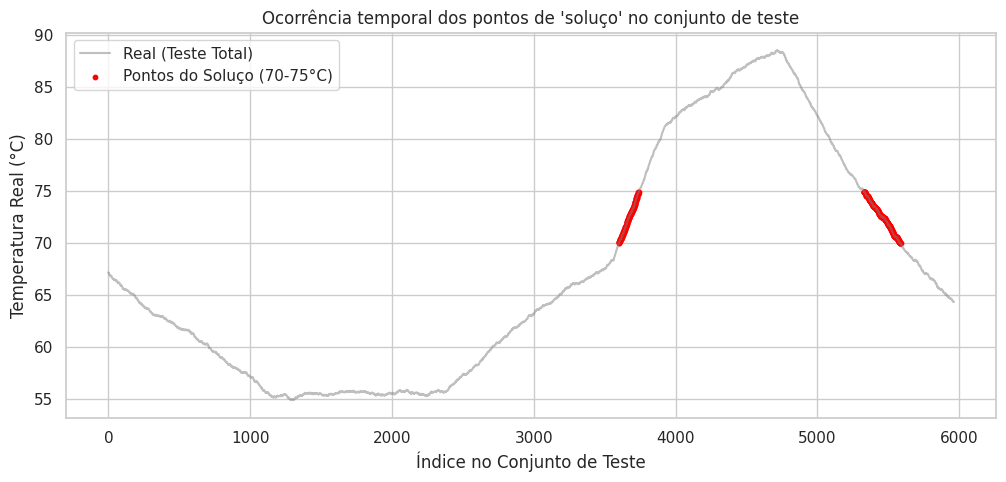

In [10]:
# Diagnóstico do soluço na faixa de 70°C a 75°C

# Criando um DataFrame temporário com os resultados do conjunto de teste
# Como o teste é isolado, pegamos o tamanho da sequência a partir de X_test
tamanho_seq_real = X_test.shape[1]
teste_indices = df.index[split_idx_raw + tamanho_seq_real:]
df_teste_analise = df.loc[teste_indices].copy()

df_teste_analise['temp_real'] = y_true_celsius.flatten()
df_teste_analise['temp_predita'] = y_pred_celsius.flatten()
df_teste_analise['erro_absoluto'] = np.abs(df_teste_analise['temp_real'] - df_teste_analise['temp_predita'])

# Filtrando a região do soluço (Real entre 70 e 75°C)
regiao_soluco = df_teste_analise[(df_teste_analise['temp_real'] >= 70) & (df_teste_analise['temp_real'] <= 75)]

print(f"Quantidade de pontos na região de soluço: {len(regiao_soluco)}")
print("\nResumo estatístico das variáveis na região do soluço:")
display(regiao_soluco[['temp_real', 'temp_predita', 'erro_absoluto', 'motor_current_a', 'rpm', 'ambient_temp_c']].describe())

# Vamos plotar a série temporal completa focado onde ocorre essa faixa para entender o contexto físico
plt.figure(figsize=(12, 5))
plt.plot(df_teste_analise['temp_real'].values, label='Real (Teste Total)', color='gray', alpha=0.5)
# Destacando os pontos de soluço em vermelho
plt.scatter(np.where((df_teste_analise['temp_real'] >= 70) & (df_teste_analise['temp_real'] <= 75))[0],
            regiao_soluco['temp_real'].values, color='red', s=10, label='Pontos do Soluço (70-75°C)')
plt.title("Ocorrência temporal dos pontos de 'soluço' no conjunto de teste")
plt.xlabel("Índice no Conjunto de Teste")
plt.ylabel("Temperatura Real (°C)")
plt.legend()
plt.show()

=== COMPARAÇÃO DE COMPORTAMENTO OPERACIONAL ===
Corrente Média Fora do Soluço: 3.38 A | No Soluço: 3.95 A
RPM Médio Fora do Soluço: 1464.74 | No Soluço: 1459.44
Potência Média Fora do Soluço: 80.94 W | No Soluço: 93.90 W


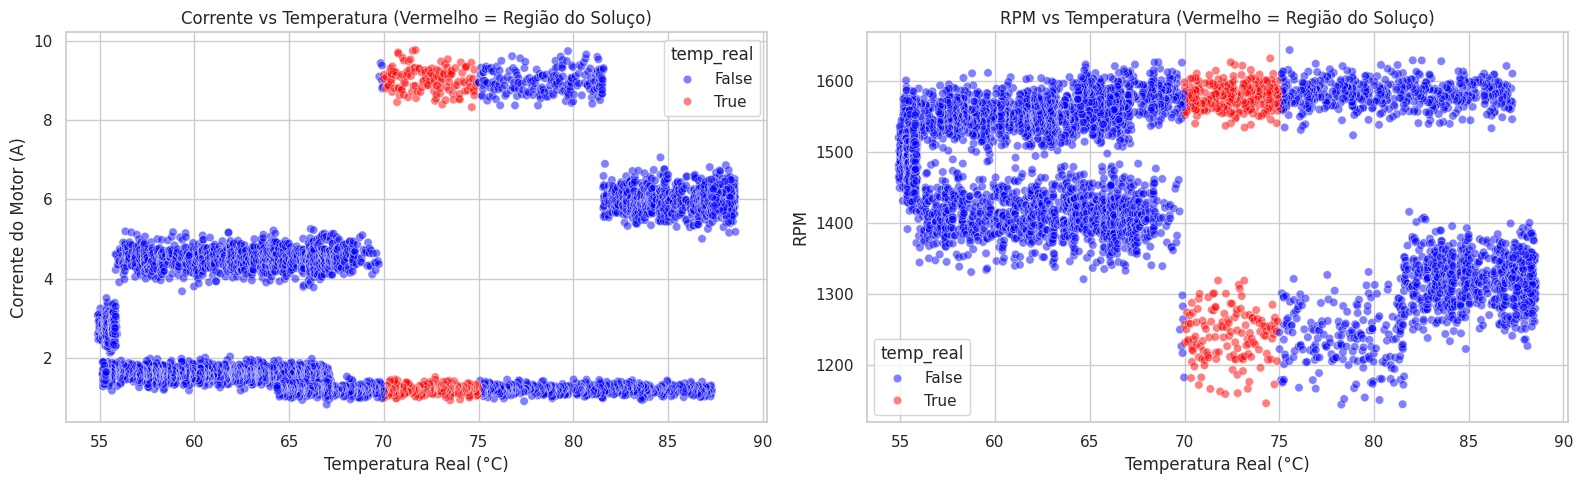

In [11]:
# Vamos comparar o comportamento físico dentro do 'soluço' vs o funcionamento normal
df_fora_soluco = df_teste_analise[~df_teste_analise.index.isin(regiao_soluco.index)]

print("=== COMPARAÇÃO DE COMPORTAMENTO OPERACIONAL ===")
print(f"Corrente Média Fora do Soluço: {df_fora_soluco['motor_current_a'].mean():.2f} A | No Soluço: {regiao_soluco['motor_current_a'].mean():.2f} A")
print(f"RPM Médio Fora do Soluço: {df_fora_soluco['rpm'].mean():.2f} | No Soluço: {regiao_soluco['rpm'].mean():.2f}")
print(f"Potência Média Fora do Soluço: {df_fora_soluco['power_w'].mean():.2f} W | No Soluço: {regiao_soluco['power_w'].mean():.2f} W")

# Vamos plotar como a Corrente e o RPM se comportam em relação à Temperatura
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Corrente vs Temperatura para ver se há transição abrupta
sns.scatterplot(ax=axes[0], data=df_teste_analise, x='temp_real', y='motor_current_a', hue=(df_teste_analise['temp_real'] >= 70) & (df_teste_analise['temp_real'] <= 75), palette={True: 'red', False: 'blue'}, alpha=0.5)
axes[0].set_title("Corrente vs Temperatura (Vermelho = Região do Soluço)")
axes[0].set_xlabel("Temperatura Real (°C)")
axes[0].set_ylabel("Corrente do Motor (A)")

# Gráfico de RPM vs Temperatura
sns.scatterplot(ax=axes[1], data=df_teste_analise, x='temp_real', y='rpm', hue=(df_teste_analise['temp_real'] >= 70) & (df_teste_analise['temp_real'] <= 75), palette={True: 'red', False: 'blue'}, alpha=0.5)
axes[1].set_title("RPM vs Temperatura (Vermelho = Região do Soluço)")
axes[1].set_xlabel("Temperatura Real (°C)")
axes[1].set_ylabel("RPM")

plt.tight_layout()
plt.show()

In [12]:
class MotorMLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(), # Achata a dimensão de sequência [batch, seq_len, features] -> [batch, seq_len * features]
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.net(x)

In [13]:
# 1. Inicializando o modelo MLP
# Tamanho de entrada é seq_len (30) * quantidade de features (8)
seq_len = X_train_t.shape[1]
num_features = X_train_t.shape[2]
input_dim = seq_len * num_features

mlp_model = MotorMLP(input_dim=input_dim)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=1e-5)
loss_fn_mlp = nn.MSELoss()

# 2. Treinamento do MLP
epochs_mlp = 100
for epoch in range(epochs_mlp):
  mlp_model.train()
  prediction = mlp_model(X_train_t)
  loss = loss_fn_mlp(prediction, y_train_t)

  mlp_optimizer.zero_grad()
  loss.backward()
  mlp_optimizer.step()

  if epoch % 10 == 0:
    print(f"MLP Epoch {epoch} | Loss (Normalizado): {loss.item():.4f}")

MLP Epoch 0 | Loss (Normalizado): 1.1204
MLP Epoch 10 | Loss (Normalizado): 0.0640
MLP Epoch 20 | Loss (Normalizado): 0.0185
MLP Epoch 30 | Loss (Normalizado): 0.0065
MLP Epoch 40 | Loss (Normalizado): 0.0039
MLP Epoch 50 | Loss (Normalizado): 0.0017
MLP Epoch 60 | Loss (Normalizado): 0.0011
MLP Epoch 70 | Loss (Normalizado): 0.0008
MLP Epoch 80 | Loss (Normalizado): 0.0006
MLP Epoch 90 | Loss (Normalizado): 0.0005


In [14]:
# 3. Avaliação do MLP no conjunto de teste
mlp_model.eval()
with torch.no_grad():
    y_pred_scaled_mlp = mlp_model(X_test_t).numpy()

# Desnormalizando as predições do MLP para Celsius
y_pred_celsius_mlp = target_scaler.inverse_transform(y_pred_scaled_mlp)

mae_mlp = mean_absolute_error(y_true_celsius, y_pred_celsius_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_true_celsius, y_pred_celsius_mlp))
erro_max_mlp = max_error(y_true_celsius, y_pred_celsius_mlp)

print("=== Métricas do MLP (em °C) ===")
print(f"MAE: {mae_mlp:.4f} °C")
print(f"RMSE: {rmse_mlp:.4f} °C")
print(f"Erro Máximo: {erro_max_mlp:.4f} °C")

=== Métricas do MLP (em °C) ===
MAE: 0.3064 °C
RMSE: 0.3900 °C
Erro Máximo: 1.4023 °C


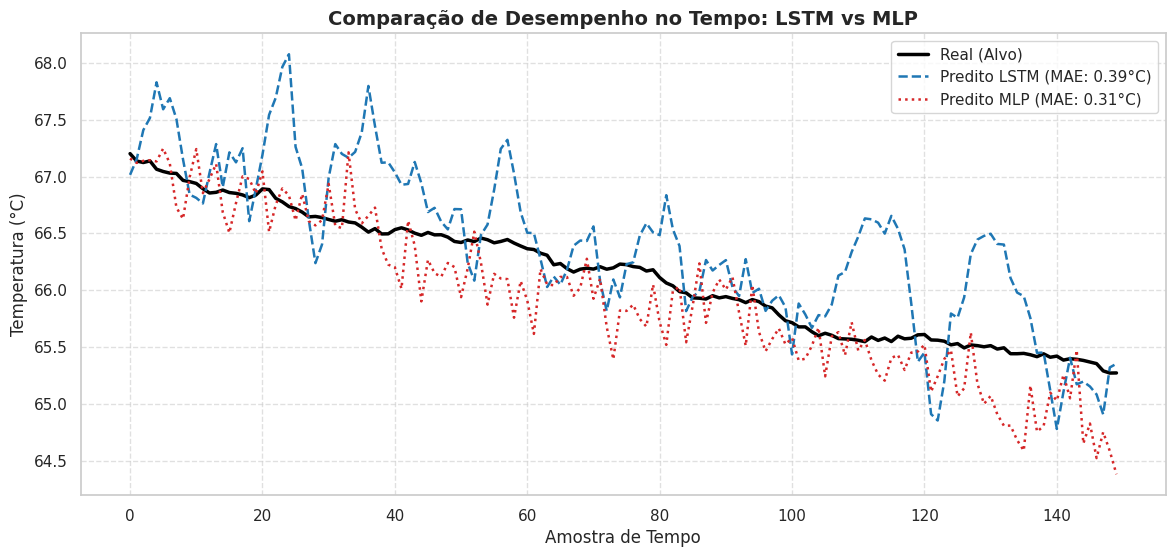

In [15]:
# 4. Comparativo Visual: LSTM vs MLP
plt.figure(figsize=(14, 6))

# Plot comparativo temporal (amostra de 150 pontos)
plt.plot(y_true_celsius[:150].flatten(), label="Real (Alvo)", color="black", linewidth=2.5)
plt.plot(y_pred_celsius[:150].flatten(), label=f"Predito LSTM (MAE: {mae_celsius:.2f}°C)", color="#1f77b4", linestyle="--", linewidth=1.8)
plt.plot(y_pred_celsius_mlp[:150].flatten(), label=f"Predito MLP (MAE: {mae_mlp:.2f}°C)", color="#d62728", linestyle=":", linewidth=1.8)

plt.title("Comparação de Desempenho no Tempo: LSTM vs MLP", fontsize=14, fontweight='bold')
plt.xlabel("Amostra de Tempo")
plt.ylabel("Temperatura (°C)")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()